In [1]:
1+3

4

### Description March 13, 2026

Use thie notebook to revisit MC / Data comparisons. 

Start with a copy of the near sideband request nb and add needed stuff for data.

### Description

March 27, 2025

I will use this notebook to make plots that will be used for making my request to access the near sideband.

Plan:

With MC, apply all cuts EXCEPT cuts I flip for s.b. and track length cut. Show that with this choice of near s.b., signal in sideband is small, even when scaled to best model benchmark. Include the CV weights and the uncertainties on signal and background MC.


Need: 

CV weights and uncertainties on both signal and bg MC. I have so many samples now, so for this exercise I should strategically choose a subset of the samples to do the study on (less processing time to get full uncertainties).

Note: I have already processed these for the nu background, and they are stored at /exp/icarus/data/users/jdyer/muon_datamc/samples_240909/allMC_ie_no_restriction_to_sideband_wConcreteFix_240909/

- the mc_coh file was made from just one of the cohlike samples (cohlike_nu_file = gray_df_dir + "F-CohLike_nom_evt.df").
- the mc_incoh never explicitly had the cohlike events masked out of it by me. But that was taken care of within the make_dataset() function. 

Here, I need to also process the CV weights and uncertainties for some signal benchmarks.



In [2]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import matplotlib as mpl
import pickle
import h5py
import math
import re
from IPython.display import display
import scipy
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.integrate import quad
from scipy.stats import poisson,norm, chi2 
from scipy.optimize import brentq
import dataframe_image as dfi


from util import *
import var
import cut
import data
import hist

import importlib

import pid
from pyanalib import panda_helpers
import os
import multiprocessing

from unc_funcs import *
from unc_samples import *
#from unc_MCdata_overhead import *
from unc_cuts import *
from alp_flux_weights import *


#import warnings
#warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)

#import subprocess

## Samples I'll use here (subset of all the samples)
(This content would normally be in unc_MCdata_overhead.py, but since I'm doing just a subset of the samples for this exercise, I'm going to contain it to this notebook.)

- Nominal nu sample: nu_file
- Cohlike nus: cohlike_nu_file
- Cohlike detector variations: cohlike_nu_detVar_files

In [3]:
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2503/'
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2510/' # These have corrected CV weights for the flux updates I included over the summer.
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2511/' # The systematics included in these are calculated with the work that is described in slides titled 211114_asymmetricFluxUnc.pptx
savedir = '/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/' # same as above, but referring to parent particle pdg for the flux weights for the bsm samples, and including the alp flux cv reweights.

## Stuff to Run Once (Prep the data dataframes):

Note: This notebook will use the stuff made by the "Stuff to Run Once" section of the near sideband notebook, which has everything needed for the simulated datasets. That stuff is removed here, to avoid redundancy between notebooks. Here, I will do that same needed stuff but for the data datasets, and save them to the same place (savedir).

In [63]:
def resave_datasets(df_names, df_list, output):
    with pd.HDFStore(output) as hdf:
        for k,df in zip(df_names, df_list):
            try:
                hdf.put(key=k, value=df, format="fixed")
            except Exception as e:
                print("Table %s failed to save, skipping. Exception: %s" % (k, str(e)))
                
                

In [86]:
# 4/3/25: make a function to do this so I don't have to copy/paste this block for every sample.

def JD_make_cvDF_w_cvWgt_and_systs(file, label, savedir=savedir, mccut=None,
                                   mc=True, mc_incoh=False, mccoh=False,
                                   bsm=False, hps=False, alp=False,
                                   onbeam=False, offbeam=False, Run1=False, Run2=False,
                                  ):
    print('file: ', file)
    evt_df = 0.
    if mc:
        evt = data.mc_dataset(file, "evt", mcnukey="mcnuwgt", isscalar=bsm, alp=alp)#, mccut=mccut)
        evt_df = evt.df
        if mccut is not None:
                print('recognized mccut')
                print('shape of evt_df before applying mccut: ', evt_df.shape)
                evt_df = evt_df[mccut(evt_df)]
                print('shape of evt_df after applying mccut: ', evt_df.shape)
    else:
        if onbeam:
            evt = data.onbeam_dataset(file, "evt")
            evt_df = evt.df
        if offbeam:
            evt = data.offbeam_dataset(file, "evt")
            evt_df = evt.df
    evt_df["mc"] = mc
    evt_df["mc_incoh"] = mc_incoh
    evt_df["mccoh"] = mccoh
    evt_df["bsm"] = bsm
    evt_df["hps"] = hps
    evt_df["alp"] = alp
    evt_df["onbeam"] = onbeam
    evt_df["offbeam"] = offbeam
    evt_df["Run1"] = Run1
    evt_df["Run2"] = Run2
    
        
    evt_df['livetime'] = evt.livetime
    evt_df['POT'] = evt.POT
    #print('livetime: ', evt.livetime)
    #print('POT: ', evt.POT)
    evt_df = evt_df[satisfies_new_FV(evt_df)] # Make sure FV definition is up to date (so that we don't accept any too-short non-fiducial events)
    when_uncontained = ~TrkInFV(evt_df.trunk.trk.end) | ~TrkInFV(evt_df.branch.trk.end) # Require exiting
    evt_df = evt_df[when_uncontained]
    evt_df = add_calculated_evtdf_cols(evt_df, mc=mc)#, newcol_name=None, newcol_val=None)

    # resave dataset with lightened evt dataframe:
    df_names = ['evt', 'hdr', 'mch', 'mcnu']
    resave_datasets(df_names, 
                    [evt_df,
                     pd.read_hdf(file, "hdr"),
                     pd.read_hdf(file, "mch"),
                     pd.read_hdf(file, "mcnu")
                    ], 
                    savedir+label
                   )
    del evt
    del evt_df


In [87]:
JD_make_cvDF_w_cvWgt_and_systs(onbeamfile_Run1, 'onbeam_run1', mc=False, onbeam=True, Run1=True)
JD_make_cvDF_w_cvWgt_and_systs(onbeamfile_Run2, 'onbeam_run2', mc=False, onbeam=True, Run2=True)
JD_make_cvDF_w_cvWgt_and_systs(offbeamfile_Run1, 'offbeam_run1', mc=False, offbeam=True, Run1=True)
JD_make_cvDF_w_cvWgt_and_systs(offbeamfile_Run2, 'offbeam_run2', mc=False, offbeam=True, Run2=True)

file:  /exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F-Run1-OnBeam_evt.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


61.88452288166666 9.71233574
2.9647510175042893 0.46516036468227545


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:637: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:637: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

file:  /exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F4-Run2-OnBeam_evt.df


...

/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:637: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:637: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

file:  /exp/icarus/data/users/gputnam/thesis-work/DMCP2023G/mc-F/F2-Run2-OffBeam_evt.df


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/pyanalib/panda_helpers.py:68: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  return lhs.merge(rhs, **panda_kwargs)


61.342936304999995 39.44877745500001
0.0 0.0


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:637: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:637: FutureWarning: Support for multi-dimensional indexing (e.g. `obj[:, None]`) is deprecated and will be removed in a future version.  Convert to a numpy array before indexing instead.
  ppdf = scalar_mom - scalar_mom.dot(BEAMDIR)[:,np.newaxis]*np.repeat([BEAMDIR], repeats=scalar_mom.shape[0], axis=0)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/di

## Every other time, start here


In [4]:
filedir = savedir
print(savedir)


/exp/icarus/data/users/jdyer/muon_CVwgts_y_systs_2512/


### Load CV dataframes: 

In [5]:
## data

onbeam_run1_evt = pd.read_hdf(filedir + "onbeam_run1", "evt")
onbeam_run1_evt['scale'] = 1
onbeam_run1_hdr = pd.read_hdf(filedir + "onbeam_run1", "hdr")

onbeam_run2_evt = pd.read_hdf(filedir + "onbeam_run2", "evt")
onbeam_run2_evt['scale'] = 1
onbeam_run2_hdr = pd.read_hdf(filedir + "onbeam_run2", "hdr")

offbeam_run1_evt = pd.read_hdf(filedir + "offbeam_run1", "evt")
offbeam_run1_evt['scale'] = np.unique(onbeam_run1_evt['livetime'])[0]/np.unique(offbeam_run1_evt['livetime'])[0]
offbeam_run1_hdr = pd.read_hdf(filedir + "offbeam_run1", "hdr")

offbeam_run2_evt = pd.read_hdf(filedir + "offbeam_run2", "evt")
offbeam_run2_evt['scale'] = np.unique(onbeam_run2_evt['livetime'])[0]/np.unique(offbeam_run2_evt['livetime'])[0]
offbeam_run2_hdr = pd.read_hdf(filedir + "offbeam_run2", "hdr")

onbeam_pot = np.unique(onbeam_run1_evt['POT'])[0] + np.unique(onbeam_run2_evt['POT'])[0]
print('Combined onbeam POT: ', onbeam_pot)
GOAL_POT = onbeam_pot

# Combine runs 1 and 2:

onbeam_evt = pd.concat([onbeam_run1_evt, onbeam_run2_evt])
onbeam_hdr = pd.concat([onbeam_run1_hdr, onbeam_run2_hdr])

offbeam_evt = pd.concat([offbeam_run1_evt, offbeam_run2_evt])
offbeam_hdr = pd.concat([offbeam_run1_hdr, offbeam_run2_hdr])


Combined onbeam POT:  2.409915937419209e+20


In [6]:
## mc_incoh

#print(h5py.File(filedir + "mc_incoh", 'r').keys())
mc_incoh_evt = pd.read_hdf(filedir + "mc_incoh", "evt") # old_251223/
mc_incoh_evt["scale"] = GOAL_POT/mc_incoh_evt.POT
mc_incoh_hdr = pd.read_hdf(filedir + "mc_incoh", "hdr") # old_251223/
#mc_incoh_evt = simpler_add_hdr_info(mc_incoh_evt, mc_incoh_hdr)

## mc_coh

mccoh_evt_1 = pd.read_hdf(filedir + "mc_coh_1", "evt") # old_251223/
mccoh_hdr_1 = pd.read_hdf(filedir + "mc_coh_1", "hdr") # old_251223/

mccoh_evt_2 = pd.read_hdf(filedir + "mc_coh_2", "evt") # old_251223/
mccoh_hdr_2 = pd.read_hdf(filedir + "mc_coh_2", "hdr") # old_251223/

total_cohlike_POT = mccoh_evt_1.POT.unique()[0] + mccoh_evt_2.POT.unique()[0]
mccoh_evt_1["scale"] = GOAL_POT/total_cohlike_POT
mccoh_evt_2["scale"] = GOAL_POT/total_cohlike_POT


In [7]:
nu_mcdfs = [pd.read_hdf(f, key="mch") for f in [nu_file, cohlike_1, cohlike_2]]   
nu_labels = ["$\\nu$",
             "Coh-like $\\nu$ (F1)", 
             "Coh-like $\\nu$ (F2)"
             ]

labels = nu_labels


### Load detector variation dataframes

In [8]:
for i, j in enumerate(detVar_labels):
    print(cohlike_nu_detVar_files[i], detVar_labels[i], sep=': ')

/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-1.df: Middle Ind. Opaque
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin0-2.df: Middle Ind. Transparent
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_ind1bin14.df: Noise 1.2x
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-1.df: Space Charge 2x
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_noiselhi-2.df: Ind0 Nom
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_sce2x-1.df: Front Ind. Gain Low
/exp/icarus/data/users/jdyer/dimuon-data/2507_remake/cohlike_sce2x-2.df: Front Ind. Gain High


In [8]:
def extract_detVar_dfs(sample):
    syst_evtdfs = []
    syst_hdrs = []
    for syst in detVar_labels:
        syst = syst.replace(' ', '_')
        evtdf = pd.read_hdf(filedir + sample + '_' + syst, "evt")
        evtdf['scale']=GOAL_POT/np.sum(evtdf.POT.unique())
        syst_evtdfs.append(evtdf)
        syst_hdrs.append(pd.read_hdf(filedir + sample + '_' + syst, "hdr"))
    return syst_evtdfs, syst_hdrs


In [9]:
mccoh_detVar_evtdfs, mccoh_detVar_hdrs = extract_detVar_dfs("mc_coh")


### Combine dataframes as needed

In [10]:
evtdfs = [
    mc_incoh_evt,
    #mccoh_evt,
    mccoh_evt_1,
    mccoh_evt_2,
    onbeam_evt,
    offbeam_evt
]

hdrs = [
    mc_incoh_hdr,
    #mccoh_hdr,
    mccoh_hdr_1,
    mccoh_hdr_2,
    onbeam_hdr,
    offbeam_hdr
]

evtdf = pd.concat(evtdfs, keys=np.arange(len(evtdfs)), names=['sample'])
evtdf.loc[evtdf.max_shw_len_all < 0., 'max_shw_len_all'] = -10



### Do interesting things

In [111]:
#evtdf.index.get_level_values('sample') == 0



In [11]:
# I need my own version of the "make categories" function, but for the different samples here.
    
# detailed_nu option will further classify the MC samples by types of neutrino interactions.

cat_colors = soladero_lime

def make_categories(df, detailed_nu = 'int_type'):
# Use this function to categorize the MC samples (signal and bg) that are used in designing the event selection.
# options for 'detailed_nu' are: 'int_type', 'final_state', 'none'. Use 'int_type!' On 4/8/25, I verfied that int_type categories are same as what's used unc_funcs (make_categories func for MC studies)
    
    # DATA
    
    #onbeam = (df.loc[[2]])
    onbeam = (df.onbeam == True)
    onbeam.name = 'Onbeam Data'
    onbeam.color = 'black' #"#E6378F"
    
    #offbeam = (df.loc[[3]])
    offbeam = (df.offbeam == True)
    offbeam.name = 'Offbeam Data'
    offbeam.color = "#EC1C0E"

    # COSMICS
    cosmic = ((df.slc.tmatch.idx < 0) & (df.mc == True) & (df.bsm==False) ) 
    cosmic.name = "Cosmic"
    cosmic.color = soladero_lime[6] #"C3"
    
    
    # NEUTRINOS
    
    is_nu = ( (df.slc.tmatch.idx >= 0) & ( df.mc_incoh | df.mccoh ) & (df.mc == True) )
    
    #mc_incoh = (df.loc[[0]]) # Doesn't work bc this needs to be a mask, not a datafram
    mc_incoh = ( (is_nu) & (df.mc_incoh == True) )
    mc_incoh.name = 'MC Incoh'
    mc_incoh.color = 'C0' #'#0F923D' # teal: '#6FE3DF'
    
    #mccoh = (df.loc[[1]])
    mccoh = ( (is_nu) & (df.mccoh == True) )
    mccoh.name = 'MC coh'
    mccoh.color = 'C1' #"#6F6FE3"
    
    if detailed_nu == 'int_type':
        
        nu_NC = (is_nu & df.mc & (df.slc.truth.iscc == 0))
        nu_NC.name = "$\\nu$ NC"
        nu_NC.color = cat_colors[0] #"#caa834" #"#EAC387"
        
        numu_CC_QE_MEC = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & ((df.slc.truth.genie_mode == 0) | (df.slc.truth.genie_mode == 10)) # CC QE+MEC
        numu_CC_QE_MEC.name = "$\\nu_\\mu$ CC QE+MEC"
        numu_CC_QE_MEC.color = cat_colors[1] 
        
        numu_CC_RES = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 1) # CC RES
        numu_CC_RES.name = "$\\nu_\\mu$ CC RES"
        numu_CC_RES.color = cat_colors[2]
        
        numu_CC_DIS = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 2) # CC DIS
        numu_CC_DIS.name = "$\\nu_\\mu$ CC DIS"
        numu_CC_DIS.color = cat_colors[3] 
        
        numu_CC_COH = is_nu & df.mc & ((df.slc.truth.pdg == 14) | (df.slc.truth.pdg == -14)) & (df.slc.truth.iscc==1) & (df.slc.truth.genie_mode == 3) # CC COH
        numu_CC_COH.name = "$\\nu_\\mu$ CC COH"
        numu_CC_COH.color = cat_colors[4]
        
        #
        nu_other = is_nu & df.mc & ~nu_NC & ~numu_CC_QE_MEC & ~numu_CC_RES & ~numu_CC_DIS & ~numu_CC_COH
        nu_other.name = "$\\nu$ Other"
        nu_other.color = cat_colors[5]  
        
        #nu_cats = [nu_NC] + [numu_CC_QE_MEC] + [numu_CC_RES] + [numu_CC_DIS] + [numu_CC_COH] + [nu_other]
        categories = [cosmic] + [nu_other] + [nu_NC] + [numu_CC_QE_MEC] + [numu_CC_RES] + [numu_CC_DIS] + [numu_CC_COH] + [onbeam] + [offbeam]
        return categories
    
    if detailed_nu == 'final_state':
        numu_cc_coh = df.mc & (df.slc.truth.genie_mode == 3) & (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool'))
        numu_cc_coh.name = '$\\nu_\\mu$ CC COH'
        numu_cc_coh.color = '#FADD28' #oranges[0]
        
        numu_cc_npizp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) &
                         (df.slc.truth.max_proton_ke < 0.02) )
        numu_cc_npizp.name = "$\\nu_\\mu$ CC n$\\pi$0p"
        numu_cc_npizp.color = oranges[1]
        
        numu_cc_npinp = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & (np.abs(df.slc.truth.pdg) == 14) & 
                         (df.slc.truth.iscc.astype('bool')) & (df.slc.truth.npi >= 1) & (df.slc.truth.npi0==0) & 
                         (df.slc.truth.max_proton_ke >= 0.02))
        numu_cc_npinp.name = '$\\nu_\\mu$ CC n$\\pi$np'
        numu_cc_npinp.color = oranges[2]
        
        numu_cc_other = (df.mc & 
                         (df.slc.truth.genie_mode != 3) & 
                         (np.abs(df.slc.truth.pdg) == 14) & (df.slc.truth.iscc.astype('bool')) & 
                         ( (df.slc.truth.npi<1) | (df.slc.truth.npi0!=0) )
                        )
        numu_cc_other.name = '$\\nu_\\mu$ CC Other'
        numu_cc_other.color = oranges[3]
        
        not_numu_cc = (df.mc & ( (np.abs(df.slc.truth.pdg) != 14) | ~df.slc.truth.iscc.astype('bool') ))
        not_numu_cc.name = 'not $\\nu_\\mu$ CC'
        not_numu_cc.color = oranges[4]
        
        #nu_cats = [numu_cc_coh] + [numu_cc_npizp] + [numu_cc_npinp] + [numu_cc_other] + [not_numu_cc]
        categories = [numu_cc_coh] + [numu_cc_npizp] + [numu_cc_npinp] + [numu_cc_other] + [not_numu_cc] + [cosmics] + [onbeam] + [offbeam]
        return categories
    
    elif detailed_nu == 'none':
        
        nu_all = is_nu
        nu_all.name = 'MC $\nu$'
        nu_all.color = 'C2' 
        
        nu_cats = [nu_all] 
        
        categories = [mc_all] + [onbeam] + [offbeam]
        return categories




In [12]:
def apply_cuts(df, cuts, thresholds=None, detailed_bsm=False, detailed_nu='none', 
               flip_last_cut=False, make_pretty_dfs=True, print_cuts=False):
    
    if make_pretty_dfs:
        #new_df = df.copy()
        categories = make_categories(df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
    
        # initialze data frames
        cut_results_df = pd.DataFrame(
            np.zeros((0,len(categories)), dtype=int), # start w/ zero rows (cuts), fill later
            columns = [c.name for c in categories]
        )
        cut_results_df_mc = cut_results_df.copy() #deep=True
        cut_results_df_pot = cut_results_df.copy() #deep=True
        cut_results_df_percent = cut_results_df.copy() #deep=True
    
        # fill in first row of data frame for "no cuts"
        row_mc = []
        row_pot = []
        for c in categories:
            row_mc.append(df[c].shape[0])
            row_pot.append(round(100*sum(df[c].scale*df[c].wgt.cv.tot))/100.)
        cut_results_df_mc.loc["preselection"] = row_mc 
        first_row_mc = row_mc
        cut_results_df_pot.loc["preselection"] = row_pot
        cut_results_df_percent.loc["preselection"] = [1.] * len(row_pot)
    
    # Loop through cuts to make rows for data frame and to make master_mask
    master_mask = None
    for i in range(len(cuts)):
        if thresholds is None:
            func_output = cuts[i](*[df])
        else: 
            func_output = cuts[i](*[df], thresh=thresholds[i])
        if flip_last_cut: #overwrite with the flip
            if i == len(cuts)-1:
                func_output = cuts[i](*[df], flip=True)
        if i==0: 
            master_mask = func_output[0]
        else:
            master_mask = master_mask & func_output[0]
        new_df = df[master_mask]
        if print_cuts:
            print(func_output[1])
        
        if make_pretty_dfs:
            new_categories = make_categories(new_df, detailed_bsm=detailed_bsm, detailed_nu=detailed_nu)
        
            row_mc = []
            row_pot = []
            for c in new_categories:
                row_mc.append(new_df[c].shape[0])
                row_pot.append(round(100*sum(new_df[c].scale*new_df[c].wgt.cv.tot))/100.)
            cut_results_df_mc.loc[func_output[1]] = row_mc
            cut_results_df_pot.loc[func_output[1]] = row_pot
            cut_results_df_percent.loc[func_output[1]] = np.array(row_mc)/np.array(first_row_mc)
        else:
            cut_results_df_mc, cut_results_df_pot, cut_results_df_percent = -1, -1, -1
            
    
    return cut_results_df_mc, cut_results_df_pot, cut_results_df_percent, master_mask 


In [15]:
temp_trkSplit_fracUnc = 0.1

## makeplot_data_MC()

In [13]:
saveplots = True
plotdir = '/exp/icarus/data/users/jdyer/muon_datamc/plots/'
def makeplot(df, var, syst_evtdfs, syst_vars, myrange, xlabel = 'x axis',
             bins = 25, vline=None, detailed_nu='int_type', do_systs=True,
             POTSTR=POTSTR, title=None, ratio_bounds=None, plotname='noname', ylabel=None,
             do_detector_variations = True
            ): # , [-1,3]
    # options for 'detailed_mc' are: 'int_type', 'cd /exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-toolsfinal_state', 'none'
   
    fig, (p0, p1) = plt.subplots(2, 1, gridspec_kw={'height_ratios': [3,1]}, sharex=True) #, figsize=(7, 6.4)
    fig.subplots_adjust(hspace=0.03)
    
    mydensity = False

    scale = df.scale.copy()
    var[np.isnan(var)] = -10
    categories = make_categories(df, detailed_nu = detailed_nu)  
    
    # APPLY EVENT SELECTION (I.E. SIDEBAND MASK!!)
    
    
    
    # DATA
        
    onbeam_data = plt.hist(var[categories[-2]], 
                           weights=scale[categories[-2]], 
                           bins=bins, alpha=0, density=mydensity, range=myrange) #don't show this, just use for data bin values.
    returned_bins = onbeam_data[1]
    bin_centers = 0.5*(returned_bins[1:] + returned_bins[:-1])
    
    offbeam_data = plt.hist(var[categories[-1]], 
                            weights=scale[categories[-1]], 
                            bins=bins, alpha=0, density=mydensity, range=myrange)
    data = np.array(onbeam_data[0]-offbeam_data[0])
    data_err = [] # statistical
    for b in range(len(returned_bins)-1):
        this_bin_events_data = (( (df.onbeam == True) | (df.offbeam == True) ) & 
                                  (np.array(var) >= returned_bins[b]) & 
                                  (np.array(var) < returned_bins[b+1])
                                 )
        bin_err = np.sqrt( np.sum( (df[this_bin_events_data].scale)**2 ) )
        data_err.append(bin_err)
    data_err = np.array(data_err)
    #print('data_err:', data_err, sep='\n')

    p0.errorbar(bin_centers, data, marker = '.', 
                yerr = data_err, 
                label="Data w/ Stat. Err.",#"$\\nu$-triggered Onbeam Data \n stat. error", 
                color='black', ls='none') # , drawstyle = 'steps-mid'
    ## plot on and offbeam data separately:
    #p0.errorbar(bin_centers, onbeam_data[0], marker = '.', 
    #            label="Onbeam Data",#"$\\nu$-triggered Onbeam Data \n stat. error", 
    #            color='blue', ls='none')
    #p0.errorbar(bin_centers, offbeam_data[0], marker = '.', 
    #            label="Offbeam Data",#"$\\nu$-triggered Onbeam Data \n stat. error", 
    #            color='yellow', ls='none')
    

    # MC
    
    if detailed_nu == 'none': histtype_str = 'step'
    else: histtype_str = 'bar'
    _ = p0.hist([var[cat] for cat in categories[:-2]], 
                weights = [df[cat].scale*df[cat].wgt.cv.tot for cat in categories[:-2]], 
                color=[cat.color for cat in categories[:-2]],
                label=[cat.name for cat in categories[:-2]],
                bins=bins, density=mydensity, histtype=histtype_str, stacked=True, range=myrange)
    try: mc = _[0][-1,:] # np.sum(np.array(_[0]), axis=0)
    except IndexError: mc = _[0]
    mc_bin_nevents = []
    mc_mask = (~categories[-2] & ~categories[-1])
    mc_evtdf = df[mc_mask]
    mc_var = var[mc_mask]
    unq = np.unique(np.array(mc_evtdf.scale))
    #print('AGAIN VERIFY THAT THIS NUMBER IS TWO: ', len(unq)) # for the two runs.
        
    # MC STATISTICAL
    
    # This way takes care of cv and scale weights, and works for any number of bins.
    mc_stat_err = []
    for b in range(len(returned_bins)-1):
        this_bin_events = ((np.array(mc_var) >= returned_bins[b]) & (np.array(mc_var) < returned_bins[b+1]))
        mc_stat_err.append(
            np.sqrt(np.sum((mc_evtdf[this_bin_events].scale * mc_evtdf[this_bin_events].wgt.cv.tot)**2)))
    mc_stat_err = np.array(mc_stat_err)
        
    # MC SYSTEMATICS
    
    if do_systs:
        
        # UNIVERSE SYSTS - these include multi-sigma, multi-sim, and morph type systematic uncertainties.
        
        # ~~~~~~ SUM OVER UNIVERSES.
        
        # ~~ separate (#coh, #xsec, #flux, #g4)
        universe_contributions = ["coh", "xsec", "flux", "g4"]
        universe_contributions_use_in_plot = ["coh xs", "other xs", "flux", "g4"]
        coh_weighted_hists = []
        xsec_weighted_hists = []
        flux_weighted_hists = []
        g4_weighted_hists = []
        universe_weighted_hists = [coh_weighted_hists, xsec_weighted_hists, flux_weighted_hists, g4_weighted_hists]
        universe_covs = []
        for uc, uni_cont in enumerate(universe_contributions):
            for col in mc_evtdf.wgt[uni_cont].columns:
                if not col[0].startswith("univ"): continue
                new_weighted_hist = plt.hist(
                    mc_var, 
                    weights = mc_evtdf.scale*mc_evtdf.wgt.cv.tot*mc_evtdf.wgt[uni_cont][col],
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                universe_weighted_hists[uc].append(new_weighted_hist[0])
            hcov = None
            # average over Universe (each Universe has a bunch of weights-based uncertainties in it)
            for i in range(len(universe_weighted_hists[uc])):
                thiscov = np.outer( mc - universe_weighted_hists[uc][i] , mc - universe_weighted_hists[uc][i] )
                if hcov is None:
                    hcov = thiscov
                else:
                    hcov += thiscov
            universe_covs.append(hcov/len(universe_weighted_hists[uc]))
        coh_cov = universe_covs[0]
        xsec_cov = universe_covs[1]
        flux_cov = universe_covs[2]
        g4_cov = universe_covs[3]
        
        ## TRK SPLITTING SYST:
        trk_split_syst = temp_trkSplit_fracUnc*mc
        
        ## ~~~~~~
                
        # BG MC DETECTOR SYSTEMATICS
        
        cohlike_hist = plt.hist(mc_var[is_coh_like_JD(mc_evtdf)], #df["mccoh"]==True],
                                weights = mc_evtdf[is_coh_like_JD(mc_evtdf)].scale * mc_evtdf[is_coh_like_JD(mc_evtdf)].wgt.cv.tot,
                                bins=bins, alpha=0, density=mydensity, range=myrange)

        frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
        
        if do_detector_variations:
        
            detsyst_hists = []
            for s, mc_detsyst_var in enumerate(syst_vars):
                #mc_detsyst_var = sdf.Snumi_angle_mcs*180./math.pi # TODO: generalize this to any var.
                new_detsyst_hist = plt.hist(
                    mc_detsyst_var, 
                    weights = syst_evtdfs[s].scale*syst_evtdfs[s].wgt.cv.tot,
                    #weights = sdf.scale, 
                    bins=bins, alpha=0, density=mydensity, range=myrange
                )
                detsyst_hists.append(new_detsyst_hist[0]/frac_cohlike_bybin)
                    
            
            # Middle Induction Transparency:
            middle_ind_cov = ( np.outer( mc - detsyst_hists[0] , mc - detsyst_hists[0] ) + 
                              np.outer( mc - detsyst_hists[1] , mc - detsyst_hists[1] ) )/2.
            # Noise High:
            noise_hi_cov = np.outer( mc - detsyst_hists[2] , mc - detsyst_hists[2] )
            # Space Charge Effect x2:
            sce_cov = np.outer( mc - detsyst_hists[3] , mc - detsyst_hists[3] )
            # Ind 0 Nom (?): # changing signal shapes on front induction to Wire Cell nominal. Our nominal (default) is garfield.
            # signal shape simulation is in wire cell (so is 2D convolution, but rn we do 1d deconv. which is not using Wire Cell.)
            ind0nom_cov = np.outer( mc - detsyst_hists[4] , mc - detsyst_hists[4] )
            ## Gain: (missing as of December 4 - sample is in progress thanks to Gray!)
            front_ind_gain_cov = ( np.outer( mc - detsyst_hists[5] , mc - detsyst_hists[5] ) + np.outer( mc - detsyst_hists[6] , mc - detsyst_hists[6] ) )/2.
            
            detector = np.sqrt( np.diag(middle_ind_cov)  
                               + np.diag(noise_hi_cov) + np.diag(sce_cov) + np.diag(ind0nom_cov) 
                               + np.diag(front_ind_gain_cov)
                              )
      
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov) +
                                      detector**2 + trk_split_syst**2
                                     )
                                      
            bg_tot_cov = (coh_cov + xsec_cov + flux_cov + g4_cov + middle_ind_cov + noise_hi_cov + 
                          sce_cov + ind0nom_cov + front_ind_gain_cov + trk_split_syst**2)
        else:
            yerr_syst_total = np.sqrt(np.diag(coh_cov) + np.diag(xsec_cov) + np.diag(flux_cov) + np.diag(g4_cov) + trk_split_syst**2)
            bg_tot_cov = coh_cov + xsec_cov + flux_cov + g4_cov + trk_split_syst**2     
        
    # TOTAL MC UNCERTAINTY
    if do_systs:
        mc_err = np.sqrt(mc_stat_err**2 + yerr_syst_total**2)
        mc_err_label = 'MC Syst. Err.' # the systematic error for the MC includes its statistical error.
            
    else:
        mc_err = mc_stat_err
        mc_err_label = 'Stat. Err.'
    #print('mc_stat_err: ', mc_stat_err, sep='\n')
    #print('mc syst. err: ', yerr_syst_total, sep='\n')
    #print('coh xs:', np.sqrt(np.diag(coh_cov)), sep='\n')
    #print('other xs:', np.sqrt(np.diag(xsec_cov)), sep='\n')
    #print('flux:', np.sqrt(np.diag(flux_cov)), sep='\n')
    #print('g4:', np.sqrt(np.diag(g4_cov)), sep='\n')
    #print('detector:', detector, sep='\n')
    #print('mc_err: ', mc_err, sep='\n')

    mc_minus_err = np.append((mc - mc_err), 0.)
    mc_minus_err[np.isnan(mc_minus_err)] = 0.
    mc_plus_err = np.append((mc + mc_err), 0.)
    mc_plus_err[np.isnan(mc_plus_err)] = 0.
    fill = p0.fill_between(onbeam_data[1], mc_minus_err, mc_plus_err,  
                           step="post", hatch="//", label = mc_err_label,
                           edgecolor="gray", facecolor="gray", alpha=0.4, linewidth=0) #label = 'MC Total Uncertainty', hatch="x", color="gray", alpha=0.5, 
    # PLOT THE DATA
    
    
    
    # RATIO
    
    rathole = data/mc # (ratio)
    #rathole_err = np.sqrt((data_err/mc)**2 + (data*mc_err/mc**2)**2)
    ## Incorporating Gray's feedback April 2026: 
    #     put systematic error bars from MC as a band around 1, and include just the data statistical error on the black ratio points.
    rathole_err = data_err/mc
    p1.errorbar( bin_centers, rathole, marker = '.', yerr = rathole_err, color='black', ls='none' )
    err_around_1 = mc_err*data/(mc*mc)
    p1.fill_between(onbeam_data[1], np.append((1-err_around_1), 0.), np.append((1+err_around_1), 0.),  
                           step="post", hatch="//", label = mc_err_label,
                           edgecolor="gray", facecolor="gray", alpha=0.4, linewidth=0)
    
    
    # CHI-SQUARED

    okay_denom = (data_err**2 + mc_err**2)>0
    ndof = (data_err**2 + mc_err**2)[okay_denom].shape[0]
    chisq = np.sum( ((mc-data)[okay_denom])**2/(data_err**2 + mc_err**2)[okay_denom] ) # denominator is total error squared.
    howgood = chisq/ndof
    p_value_upper = chi2.sf(chisq, ndof) # this does a right-tailed test by default. Okay?
    print( 'chi2 over n = %a' % howgood )
    print('p_value_upper = %a' % p_value_upper)
    #if xs != None:
    #    p0.text(xs[0], xs[1], "$\\chi^2/n$ = %.3f / %i" % (chi2, ndof), fontsize=14)#, transform=plt.transAxes)
        
    ##plt.legend()
    fs = 14
    if title is not None:
        p0.set_title(title)
    plt.xlabel(xlabel, fontsize=fs)
    if ylabel is not None:
        p0.set_ylabel(ylabel+" / %s" % POTSTR, fontsize=fs)
    else:
        p0.set_ylabel("Events / %s" % POTSTR, fontsize=fs)
    p1.set_ylabel("Data / MC", fontsize=fs)
    if ratio_bounds is not None:
        p1.set_ylim(ratio_bounds)
    else:
        p1.set_ylim([-6,8])
    
    p1.axhline([1], linestyle=":", color="black", alpha=0.5, linewidth=2) # color="r"
    #p0.set_yscale("log")
    if (vline is not None):
        for line in vline:
            p0.axvline([line], linestyle=":", color="r", linewidth=2)
            p1.axvline([line], linestyle=":", color="r", linewidth=2)
    #plt.axvline([NuMI_angle_thresh], linestyle=":", color="r", linewidth=2)
    #plt.text(0.6, 0.4, label, transform=plt.gca().transAxes, fontsize=18)
    plt.tight_layout()
    plt.xlim(myrange)
    
    #box = ax.get_position()
    #ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #ax.legend(loc = 'center left', bbox_to_anchor=(1, 0.5))
    
    # legend documentation: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.legend.html
    box = p0.get_position()
    p0.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    #p0.legend(loc = 'center left', bbox_to_anchor=(1, 0.5)) # 2-tuple (x,y) of bbox_to_anchor places the corner of the legend specified by 'loc' at (x,y)
    p0.legend(loc='lower center', bbox_to_anchor=(0.5, 1.03), ncol=3, fontsize='x-small')
    box = p1.get_position()
    p1.set_position([box.x0, box.y0, box.width * 0.8, box.height])
    
    p0.text(0.64, 0.96, "ICARUS Data", fontsize=14,
            transform=p0.transAxes, verticalalignment="top")
    p0.text(0.64, 0.81, "$\\chi^2/n$ = %.1f/%i" % (chisq, ndof), fontsize=12, transform=p0.transAxes)#
    #p0.text(0.64, 0.71, "p-value = %.2f" % p_value_upper, fontsize=12, transform=p0.transAxes)
    
    if saveplots: 
        print('plotdir+plotname: \n', plotdir+plotname)
        plt.savefig(plotdir + plotname + ".png", format='png', bbox_inches='tight', dpi=350)
    plt.show()
    
    #return hsyst, cov

In [27]:
print(plotdir)

/exp/icarus/data/users/jdyer/muon_datamc/plots/


In [27]:
# APPLY THE FAR SIDEBAND

#fsb_df = evtdf[evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi > 15.]
fsb_df = evtdf[(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi > 15.) &
               (evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi < 50.)
              ]

fsb_mccoh_detVar_evtdfs = [
    sdf[(sdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi > 15.) &
        (sdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi < 50.)
    ] for sdf in mccoh_detVar_evtdfs
]


<class 'list'>


In [20]:
# APPLY THE NEAR SIDEBAND
# NO CUT ON THETA_NUMI IS MADE HERE - ENFORCE THAT IN YOUR PLOTTING RANGES.
# WIP May 7, 2026

nsb_cuts = [ # cut list
            not_stub_05, not_stub_1, not_stub_2, not_stub_3,
            max_shw_len_mask,
            ok_chi2mu_contained,
            open_angle_mask, # corrected this from numi_angle_mcsCorr_mask October 31, 2025
            shortTrk_len_mask
        ]
nsb_thresholds = [ # thresholds
    50, 35, 15, 10,
    0.0,
    8,
    25,
    100.0
]
 

cut_results = apply_cuts(evtdf, nsb_cuts, thresholds=nsb_thresholds,
                         detailed_nu='none', print_cuts=True, make_pretty_dfs=False) # detailed_nu='none', detailed_nu='int_type'
#cut_results = apply_cuts(evtdf, cut_list_noTrkLenCut, detailed_hps=True, flip_last_cut=False)
mask = cut_results[-1]
mc_res = cut_results[0]
pot_res = cut_results[1]
percent_res = cut_results[2]
#final_df = add_hdr_info(evtdf)
nsb_df = add_hdr_info(evtdf[mask], hdrs)

print(min(nsb_df.Snumi_angle_hybrid_rangeCorrectedMCS)*180./math.pi)

###

#fsb_df = evtdf[evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi > 15.]
#fsb_df = evtdf[(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi > 15.) &
#               (evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi < 50.)
#              ]

#fsb_mccoh_detVar_evtdfs = [
#    sdf[(sdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi > 15.) &
#        (sdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi < 50.)
#    ] for sdf in mccoh_detVar_evtdfs
#]

dE/dx <= 50 MeV/cm up to 0_5 cm
dE/dx <= 35 MeV/cm 0_5-1 cm
dE/dx <= 15 MeV/cm 1-2 cm
dE/dx <= 10 MeV/cm 2-3 cm
max shower len < 0.0 cm
contained trk chi2mu < 8
opening angle < 25 deg
shorter of tracks > 100.0 cm


/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/env/lib64/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in arccos
  result = getattr(ufunc, method)(*inputs, **kwargs)
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:152: PerformanceWarning: indexing past lexsort depth may impact performance.
  p = hdrs[idx[0]].loc[(idx[1],idx[2])].proc
/exp/icarus/app/users/jdyer/dev_new_sbnana_v09_69_01/srcs/sbnana/sbnana/SBNAna/icarus-analysis-villiage/pyana/dimuon-tools/nb/unc_funcs.py:153: PerformanceWarning: indexing past lexsort depth may impact performance.
  c = hdrs[idx[0]].loc[(idx[1],idx[2])].cluster


0.47312613658972547


In [25]:
print(np.min(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi))
print(np.min(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi))
print(np.min(nsb_df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi))
print('')
print(np.min(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS))
print(np.min(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS))
print(np.min(nsb_df.Snumi_angle_hybrid_rangeCorrectedMCS))


0.09278741
0.09278741
0.4731261

0.0016194459
0.0016194459
0.008257609


In [50]:
for s, sfd in enumerate(fsb_mccoh_detVar_evtdfs):
    print(mccoh_detVar_evtdfs[s].shape[0], sfd.shape[0], sep=', ')
    

88875, 43322
96018, 46804
98624, 48033
98925, 48782


In [124]:
print(evtdf.shape)
print(fsb_df.shape)
print(min(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi), 
      max(evtdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi), 
      sep=', ')
print(min(fsb_df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi), 
      max(fsb_df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi), 
      sep=', ')

(391733, 831)
(117764, 831)
0.09278740733861923, 179.9657440185547
15.00009536743164, 49.999855041503906


NameError: name 'temp_trkSplit_fracUnc' is not defined

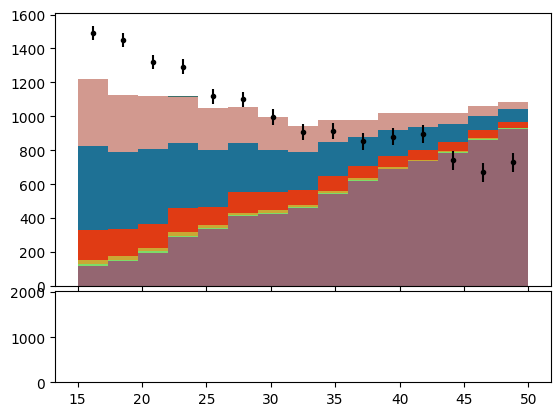

In [29]:
x = makeplot(fsb_df, fsb_df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         fsb_mccoh_detVar_evtdfs, [sdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for sdf in fsb_mccoh_detVar_evtdfs],
         (15.,50.), bins=15,
         xlabel = "$\\theta_\mathrm{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.5,1.5], plotname='fsb_theta_NuMI'
        )

chi2 over n = 2.0795838356276195
p_value_upper = 0.008274946062224783
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb_theta_NuMI


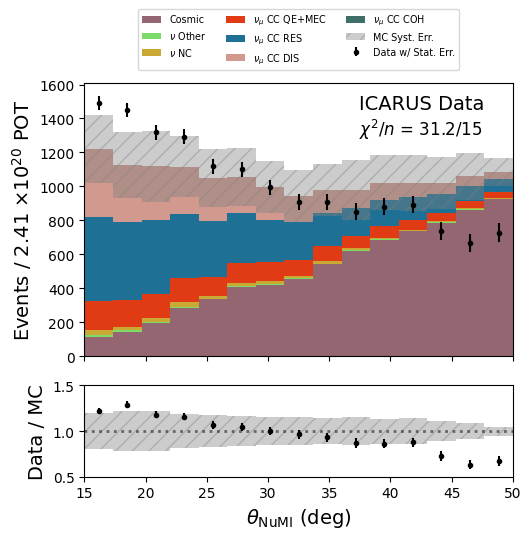

In [16]:
x = makeplot(fsb_df, fsb_df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi,
         fsb_mccoh_detVar_evtdfs, [sdf.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi for sdf in fsb_mccoh_detVar_evtdfs],
         (15.,50.), bins=15,
         xlabel = "$\\theta_\mathrm{NuMI}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.5,1.5], plotname='fsb_theta_NuMI'
        )

In [ ]:
List of Vars:
    
df.stub.l0_5cm.dedx
df.stub.l1cm.dedx
df.stub.l2cm.dedx
df.stub.l3cm.dedx
df.max_shw_len_all
df.conTrk_chi2pid_I2_chi2_muon
df.Snumi_angle_hybrid_rangeCorrectedMCS*180./math.pi
np.arccos(dotdf(df.trunk.trk.dir, df.branch.trk.dir))*180./math.pi
df.shorter_track_length

chi2 over n = 0.5089502563007026
p_value_upper = 0.937607843791844
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb_dEdx_0


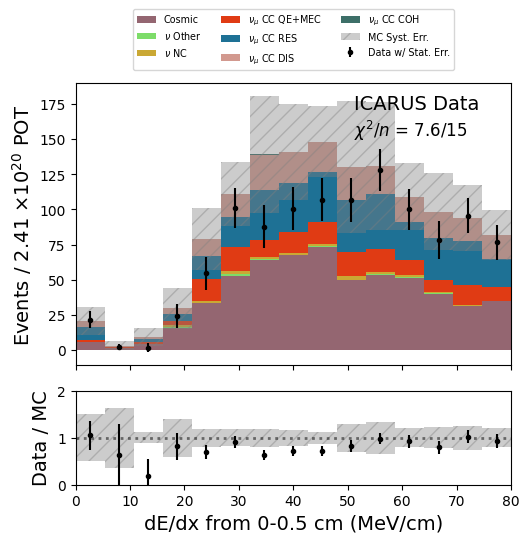

chi2 over n = 0.46858866377791597
p_value_upper = 0.9568447942610346
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb__dEdx_1


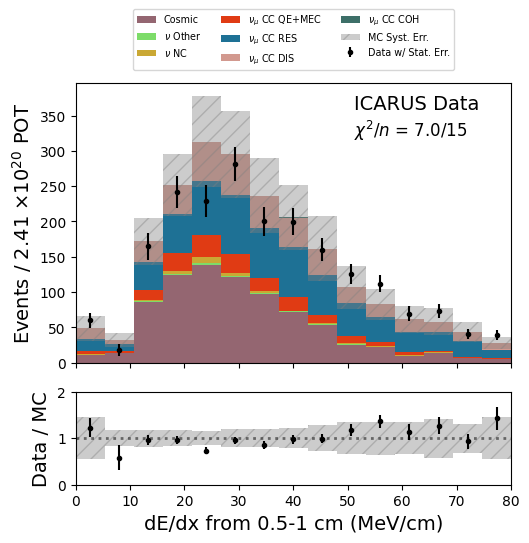

chi2 over n = 0.2590230343162077
p_value_upper = 0.9980891044577597
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb__dEdx_2


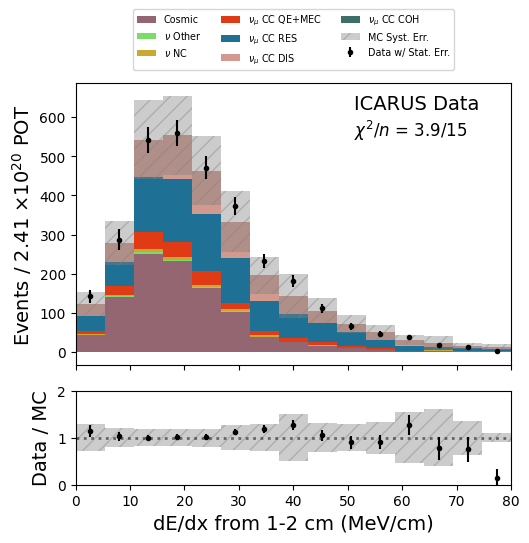

chi2 over n = 0.4141609714676134
p_value_upper = 0.9759544807788821
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb__dEdx_3


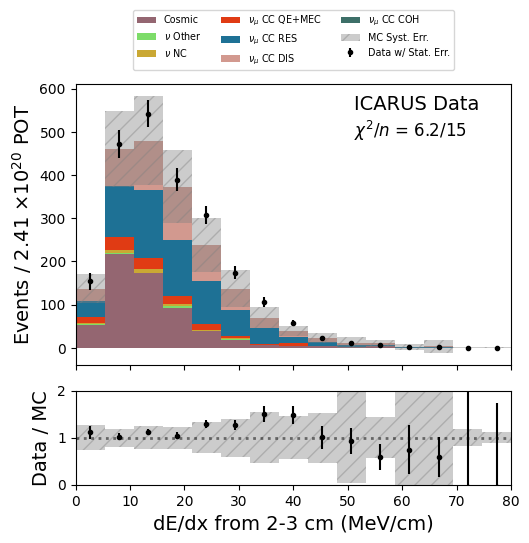

In [19]:
x = makeplot(fsb_df, fsb_df.stub.l0_5cm.dedx,
         fsb_mccoh_detVar_evtdfs, [sdf.stub.l0_5cm.dedx for sdf in fsb_mccoh_detVar_evtdfs],
         (0,80.), bins=15,
         xlabel = "dE/dx from 0-0.5 cm (MeV/cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb_dEdx_0'
        )
x = makeplot(fsb_df, fsb_df.stub.l1cm.dedx,
         fsb_mccoh_detVar_evtdfs, [sdf.stub.l1cm.dedx for sdf in fsb_mccoh_detVar_evtdfs],
         (0,80.), bins=15,
         xlabel = "dE/dx from 0.5-1 cm (MeV/cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb__dEdx_1'
        )
x = makeplot(fsb_df, fsb_df.stub.l2cm.dedx,
         fsb_mccoh_detVar_evtdfs, [sdf.stub.l2cm.dedx for sdf in fsb_mccoh_detVar_evtdfs],
         (0,80.), bins=15,
         xlabel = "dE/dx from 1-2 cm (MeV/cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb__dEdx_2'
        )
x = makeplot(fsb_df, fsb_df.stub.l3cm.dedx,
         fsb_mccoh_detVar_evtdfs, [sdf.stub.l3cm.dedx for sdf in fsb_mccoh_detVar_evtdfs],
         (0,80.), bins=15,
         xlabel = "dE/dx from 2-3 cm (MeV/cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb__dEdx_3'
        )

/tmp/ipykernel_1011436/75874247.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var[np.isnan(var)] = -10
/tmp/ipykernel_1011436/75874247.py:138: RuntimeWarning: invalid value encountered in divide
  frac_cohlike_bybin = np.array(cohlike_hist[0]/mc)
/tmp/ipykernel_1011436/75874247.py:211: RuntimeWarning: invalid value encountered in divide
  rathole = data/mc # (ratio)
/tmp/ipykernel_1011436/75874247.py:215: RuntimeWarning: invalid value encountered in divide
  rathole_err = data_err/mc


chi2 over n = 0.4696431783113503
p_value_upper = 0.8958617152149555
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb_shwLen


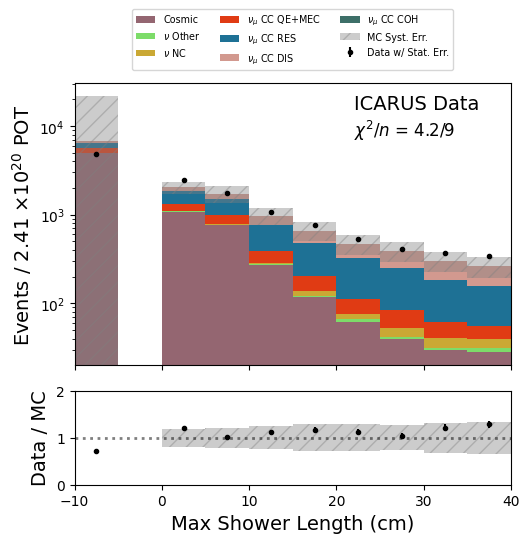

In [25]:
#x = makeplot(fsb_df, fsb_df.max_shw_len_all,
#         fsb_mccoh_detVar_evtdfs, [sdf.max_shw_len_all for sdf in fsb_mccoh_detVar_evtdfs],
#         (0,40.), bins=15,
#         xlabel = "Max Shower Length (cm)", detailed_nu="int_type",
#         ratio_bounds=[0.,2.], plotname='fsb_shwLen'
#        )

# Note: Set the yscale to log inside plotting function for this plot!

x = makeplot(fsb_df, fsb_df.max_shw_len_all,
         fsb_mccoh_detVar_evtdfs, [sdf.max_shw_len_all for sdf in fsb_mccoh_detVar_evtdfs],
         (-10, 40), bins=10,
         xlabel = "Max Shower Length (cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb_shwLen'
        )

/tmp/ipykernel_1011436/3514844859.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var[np.isnan(var)] = -10


chi2 over n = 0.22114414056364146
p_value_upper = 0.9992546671779795
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb_muPID


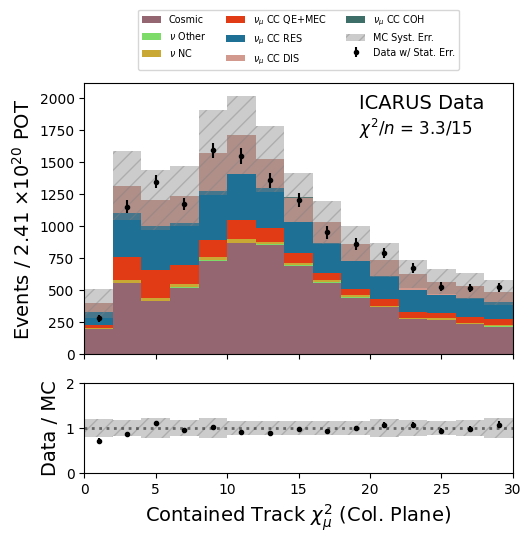

In [21]:
x = makeplot(fsb_df, fsb_df.conTrk_chi2pid_I2_chi2_muon,
         fsb_mccoh_detVar_evtdfs, [sdf.conTrk_chi2pid_I2_chi2_muon for sdf in fsb_mccoh_detVar_evtdfs],
         (0,30.), bins=15,
         xlabel = "Contained Track $\\chi^2_\\mu$ (Col. Plane)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb_muPID'
        )

chi2 over n = 0.5919573263215819
p_value_upper = 0.8837403407327684
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb_openangle


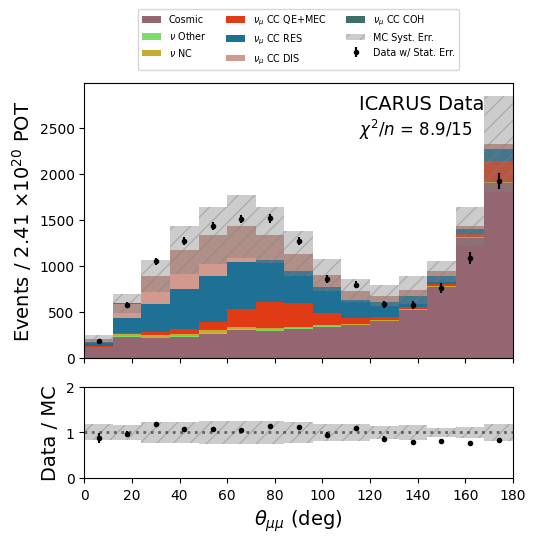

In [22]:
x = makeplot(fsb_df, np.arccos(dotdf(fsb_df.trunk.trk.dir, fsb_df.branch.trk.dir))*180./math.pi,
         fsb_mccoh_detVar_evtdfs, [np.arccos(dotdf(sdf.trunk.trk.dir, sdf.branch.trk.dir))*180./math.pi for sdf in fsb_mccoh_detVar_evtdfs],
         (0,180.), bins=15,
         xlabel = "$\\theta_{\mu\mu}$ (deg)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb_openangle'
        )

/tmp/ipykernel_1011436/3514844859.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  var[np.isnan(var)] = -10


chi2 over n = 0.6110467534653752
p_value_upper = 0.8686951832361909
plotdir+plotname: 
 /exp/icarus/data/users/jdyer/muon_datamc/plots/fsb_trkLen


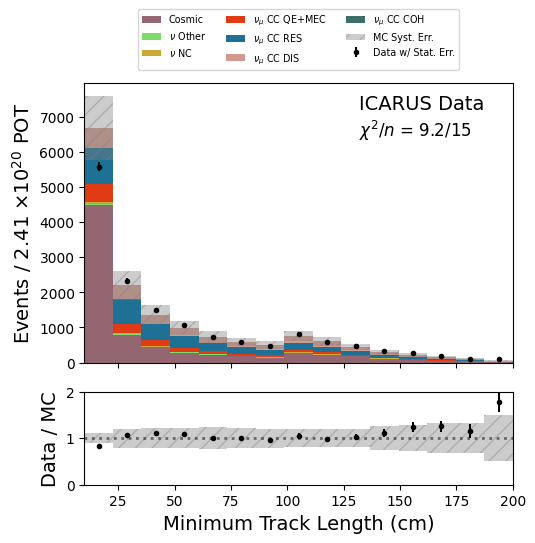

In [23]:
x = makeplot(fsb_df, fsb_df.shorter_track_length,
         fsb_mccoh_detVar_evtdfs, [sdf.shorter_track_length for sdf in fsb_mccoh_detVar_evtdfs],
         (10,200), bins=15,
         xlabel = "Minimum Track Length (cm)", detailed_nu="int_type",
         ratio_bounds=[0.,2.], plotname='fsb_trkLen'
        )
